229.85800083049833
54.489999999999995


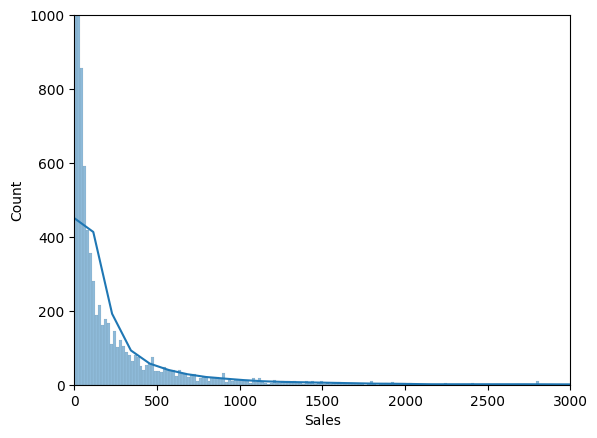

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("data.csv", encoding ='cp1252')

sns.histplot(data=df, x="Sales", kde=True)
plt.xlim(0, 3000)
plt.ylim(0,1000)
mean=np.mean(df['Sales'])
median=np.median(df['Sales'])
print(mean)
print(median)

it is right skewed graph and because there are more outliers it has a bigger mean value

task2

(-2000.0, 4000.0)

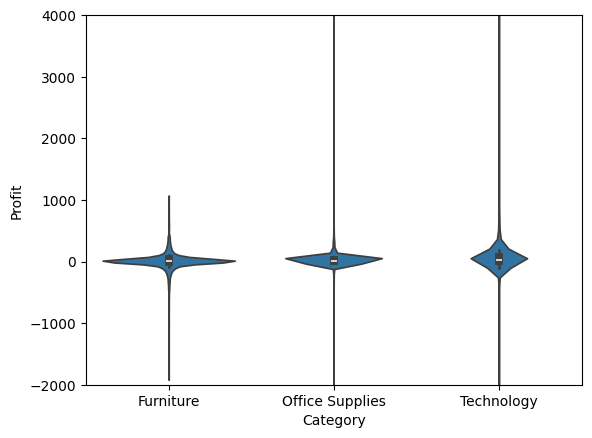

In [15]:
sns.violinplot(data=df, x="Category", y="Profit")
plt.ylim(-2000,4000)



<Axes: xlabel='Category', ylabel='Profit'>

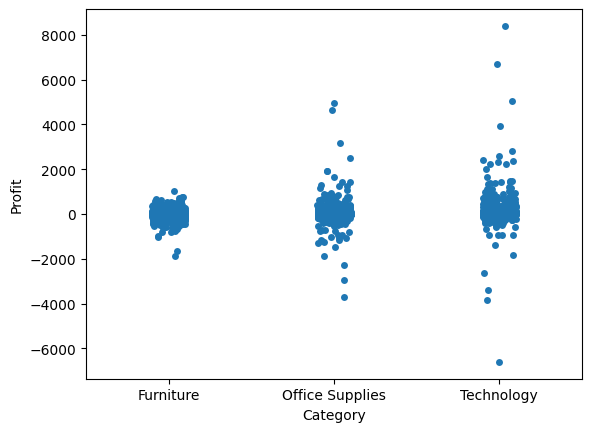

In [14]:
sns.stripplot(data=df, x="Category", y="Profit")

task 3


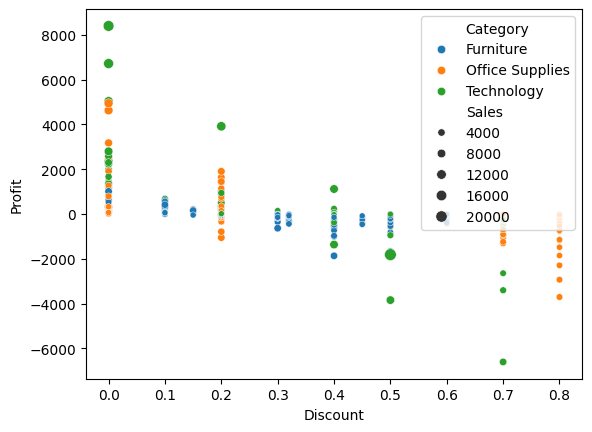

In [22]:
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", size="Sales")
plt.legend(loc="upper right")

when you give more discount to techology it is giving lesser profit

task 4

<Axes: >

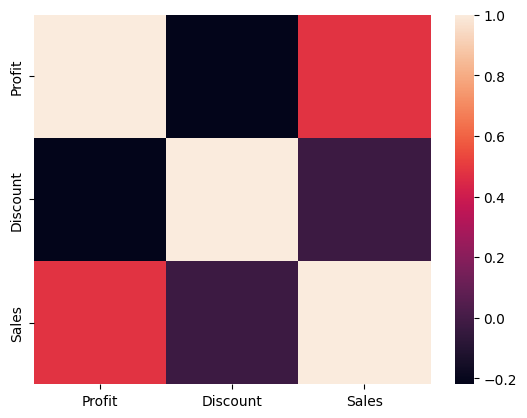

In [23]:
nums=['Profit', 'Discount', 'Sales']
pearson_matrix=df[nums].corr(method="pearson")
spearman_matrix=df[nums].corr(method="spearman")
sns.heatmap(pearson_matrix)

<Axes: >

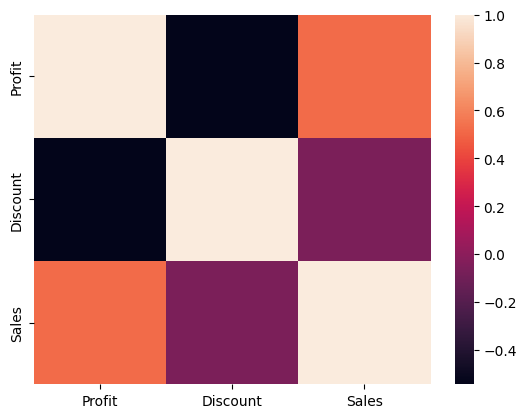

In [24]:
sns.heatmap(spearman_matrix)

<Axes: xlabel='Discount', ylabel='Profit'>

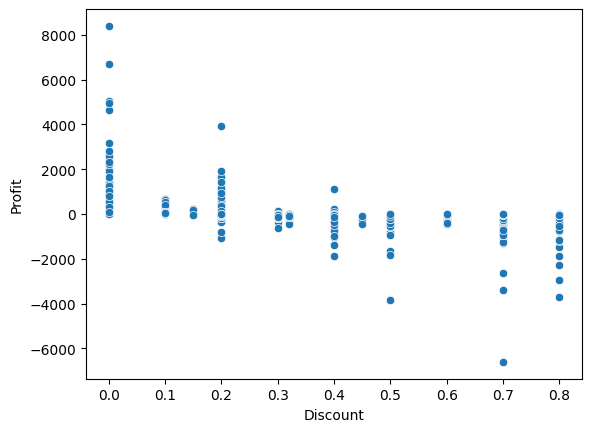

In [26]:
sns.scatterplot(data=df, x="Discount", y="Profit")

since pearson is more sensitive to outliers and it focuses more on linear quations, it gives different amount.

task5

In [40]:
table=pd.pivot_table( data=df, values="Sales", columns='Category',index='Region', aggfunc=sum, margins=True)
print(table)

Category    Furniture  Office Supplies  Technology           All
Region                                                          
Central   163797.1638       167026.415  170416.312  5.012399e+05
East      208291.2040       205516.055  264973.981  6.787812e+05
South     117298.6840       125651.313  148771.908  3.917219e+05
West      252612.7435       220853.249  251991.832  7.254578e+05
All       741999.7953       719047.032  836154.033  2.297201e+06


/tmp/ipykernel_3011/1702064316.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table=pd.pivot_table( data=df, values="Sales", columns='Category',index='Region', aggfunc=sum, margins=True)
/tmp/ipykernel_3011/1702064316.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table=pd.pivot_table( data=df, values="Sales", columns='Category',index='Region', aggfunc=sum, margins=True)
/tmp/ipykernel_3011/1702064316.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behav

<Axes: xlabel='Category', ylabel='Region'>

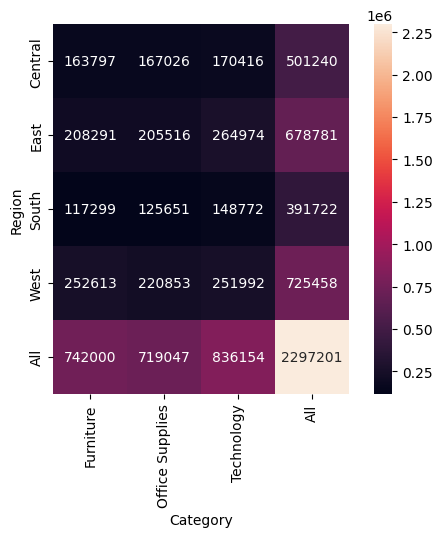

In [43]:

sns.heatmap(data=table, annot=True, square=True, fmt='.0f' )

eastt-technology has highest revenue

task 6

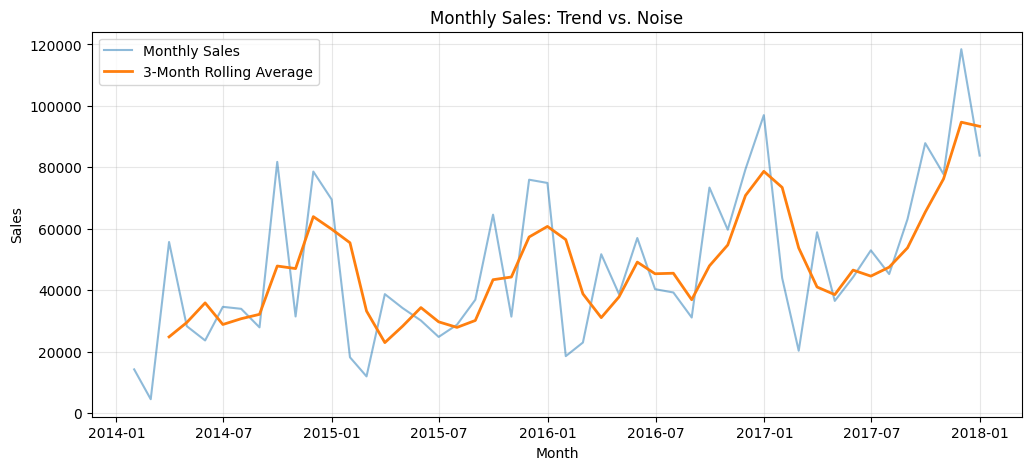

In [44]:

df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.set_index('Order Date')

monthly_sales = df['Sales'].resample('ME').sum()
rolling_3m = monthly_sales.rolling(3).mean()
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales, label='Monthly Sales', alpha=0.5)
plt.plot(rolling_3m, label='3-Month Rolling Average', linewidth=2)

plt.title('Monthly Sales: Trend vs. Noise')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


 It reveals whether sales are generally increasing or decreasing without the noise and month-to-month spikes visible in the raw monthly line.

task7

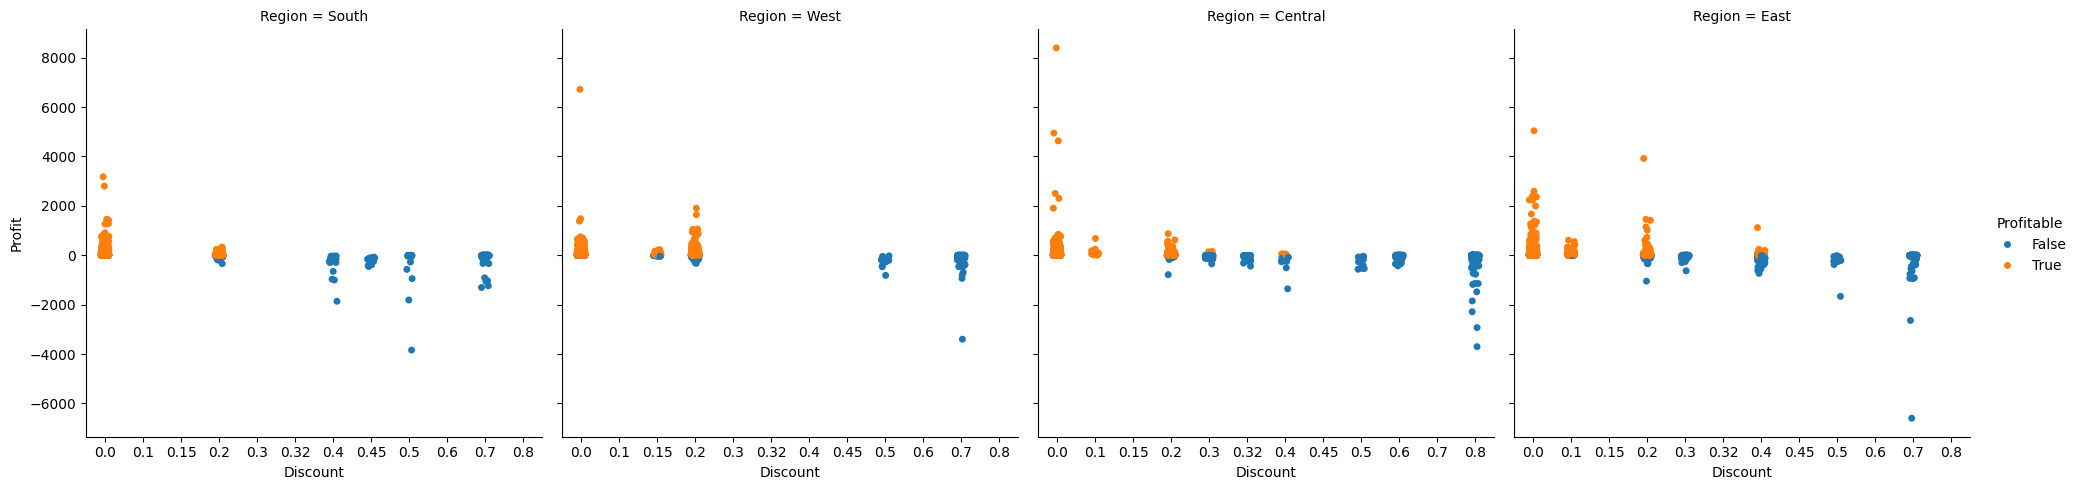

In [49]:
df['Profitable'] = df['Profit'] > 0
sns.catplot(data=df, x='Discount', y='Profit', col='Region', hue='Profitable', kind='strip', aspect=1)


The Central region visibly differs from the others

task 8

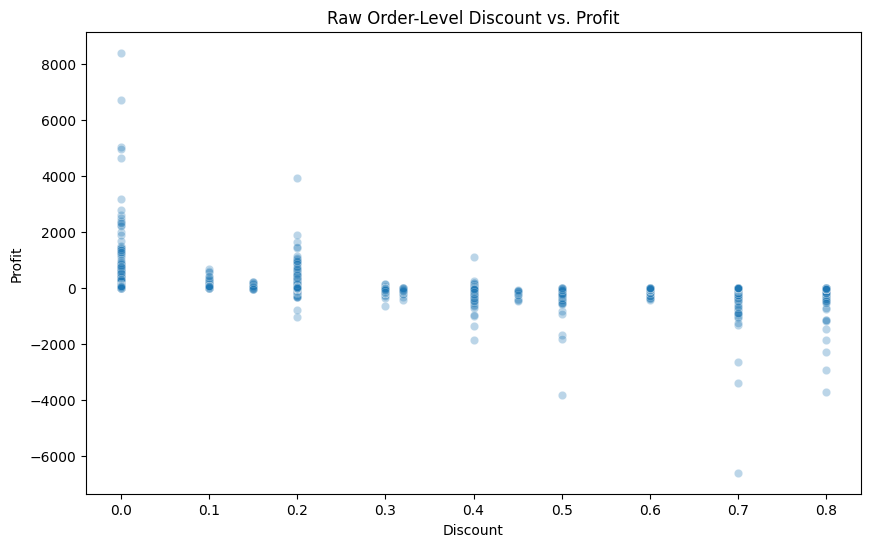

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.3
)

plt.title('Raw Order-Level Discount vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()


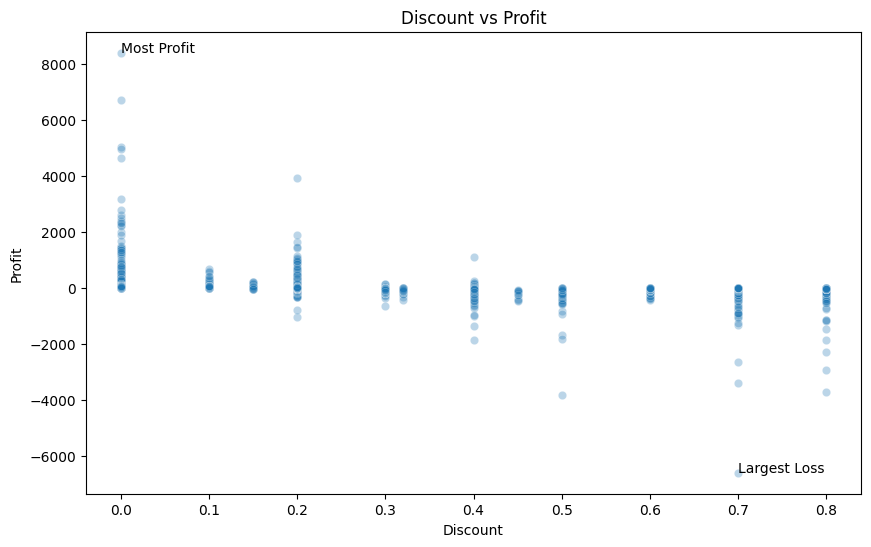

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3)

best = data.loc[data['Profit'].idxmax()]
worst = data.loc[data['Profit'].idxmin()]

plt.annotate('Most Profit',
             (best['Discount'], best['Profit']))

plt.annotate('Largest Loss',
             (worst['Discount'], worst['Profit']))

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')

plt.show()



i have used alpha to fix this overplotting. this way there is less overplotting in the graph tho nly by a litle